In [1]:
from occultence import *
import occultence
occultence.version()

'0.5.4'

(0.99, 1.015)

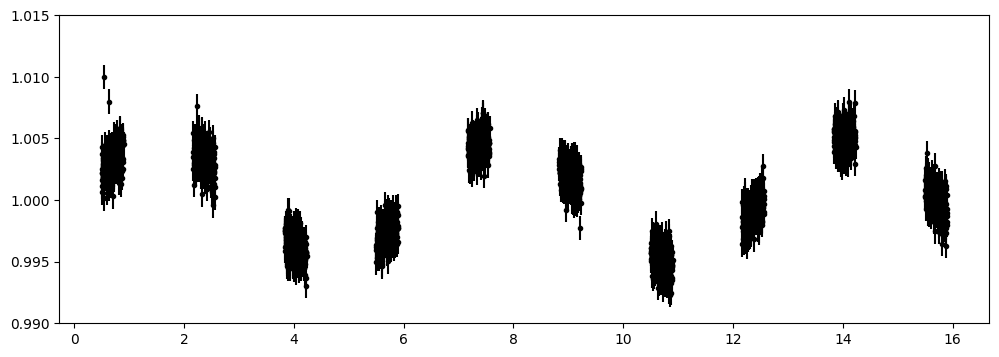

In [2]:
t = list(np.linspace(0.5,0.9,200))
daylength = len(t)
ndays = 10
gap = 16/24.
A = 0.005

for d in range(1,ndays):
    t.extend(np.array(t[:daylength]) + d * (1 + gap))

t = np.array(t)
ferr = 1e-3 * np.ones(len(t))
sinusoid_trend = A * np.sin(t)
f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
f[22] = 1.01 # add a cosmic
f[63] = 1.008 # add a cosmic
f[50] = 0.0 # add a zero flux point

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/occultence/flare_finding/flare_model.py:207: RuntimeWarning: overflow encountered in exp
  * np.exp(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

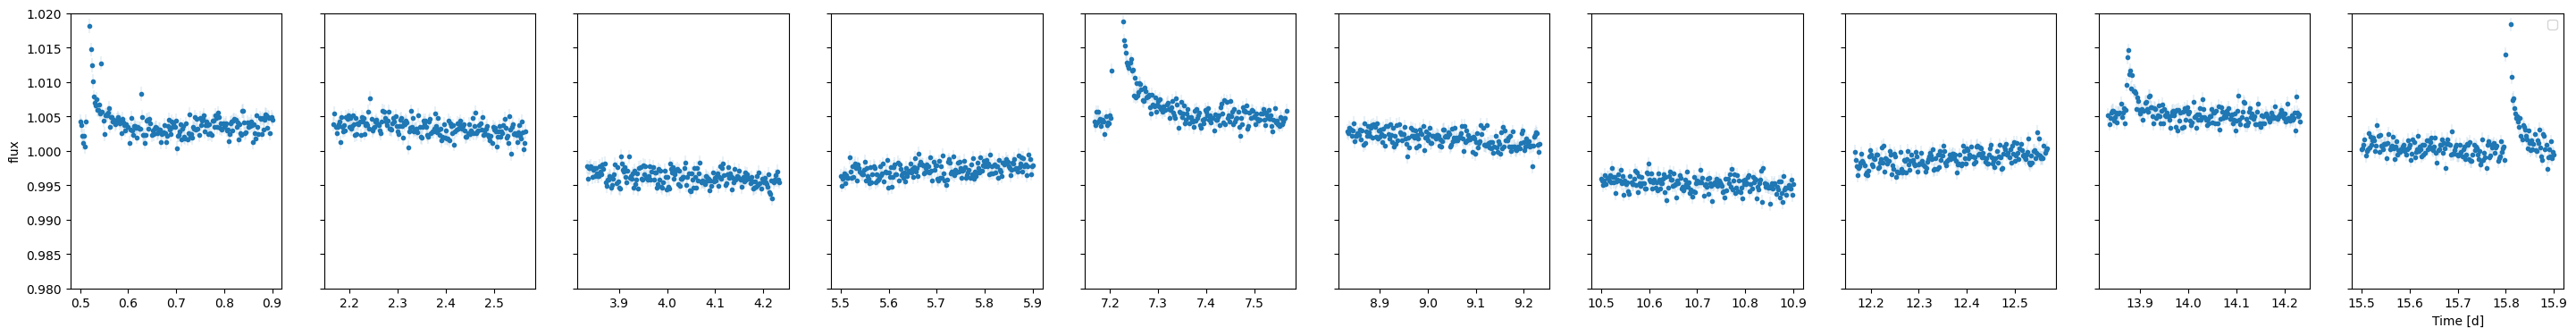

In [4]:
flare_lc = targ.inject_flares(nfake=5, amp_range=[1e-3, 0.05], model="mendoza2022")
flare_lc.plot()

In [5]:
flare_lc.metadata

{'name': 'test_injectedflares',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [0.514964420692815,
    15.802008261979937,
    13.874845494044044,
    7.207320422217878,
    7.214765217131041],
   'fwhm': [0.0058212179384868525,
    0.006796428235003637,
    0.010804419444843597,
    0.011839557098117346,
    0.006137632550858874],
   'amp': [0.035636103611340085,
    0.04667856624837055,
    0.009535485424857593,
    0.028856248992313236,
    0.04204272219851864]}}}

In [6]:
flare_lc.split_by

<Quantity 0.5 d>

In [7]:
i_split, _ = flare_lc.split_time(split=flare_lc.split_by)
i_split

[0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]

In [8]:
clip_lc = flare_lc.global_and_local_sigma_clip(global_sc_kw={'nsigma_upper':5, 
                                                             'nsigma_lower':5},
                                               local_sc_kw={'nsigma_upper':3, 
                                                            'nsigma_lower':np.inf, 
                                                            'running_mean_boxsize':0.4}
                                              )

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

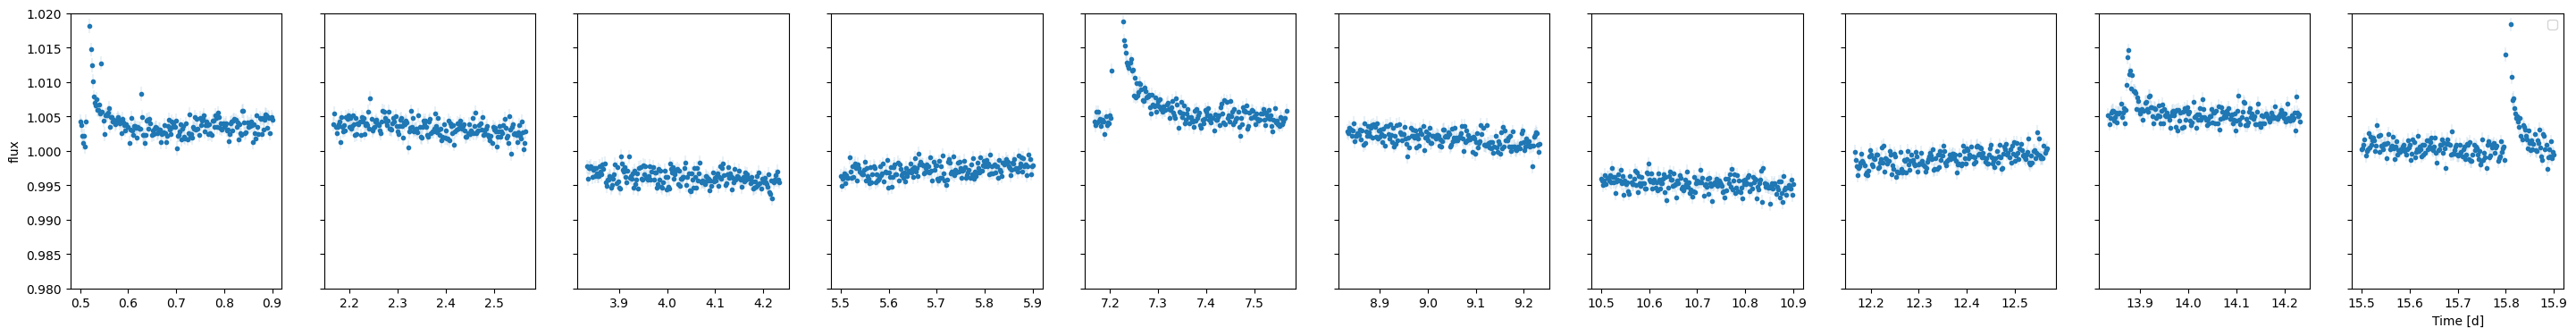

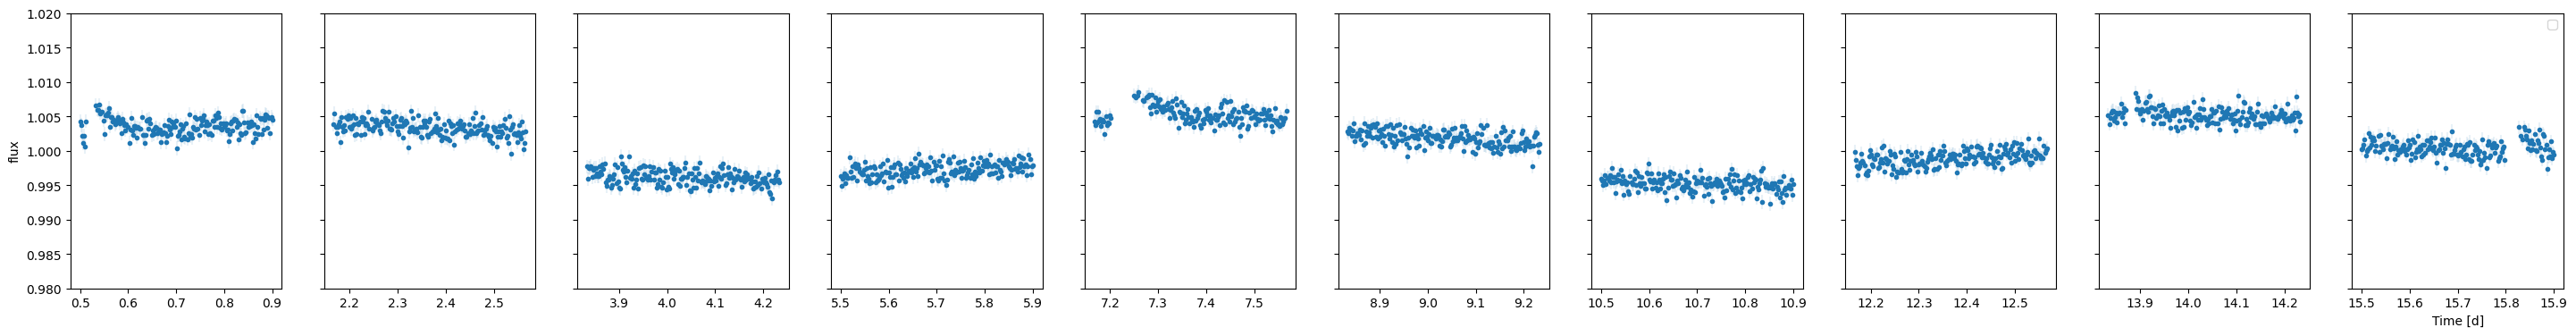

In [9]:
flare_lc.plot()
clip_lc.plot()

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


The best recovered period=6.379856115107913 d


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


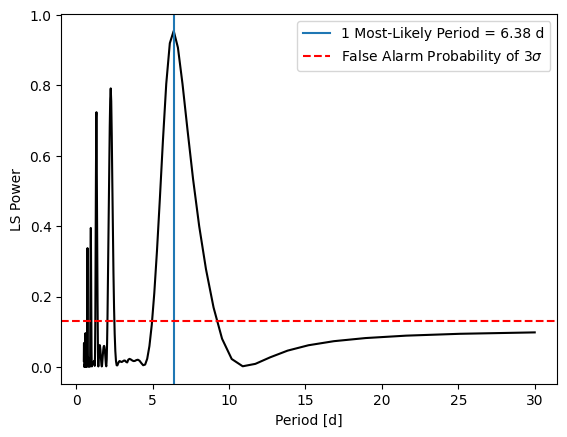

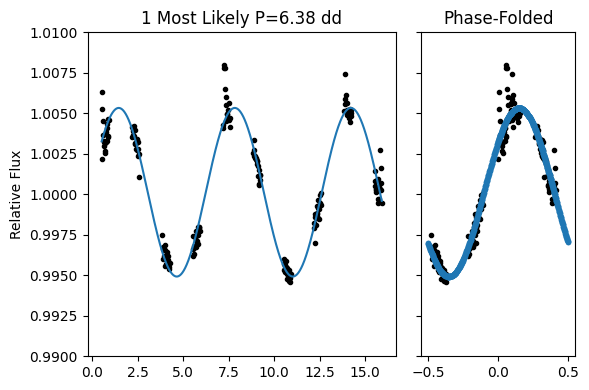

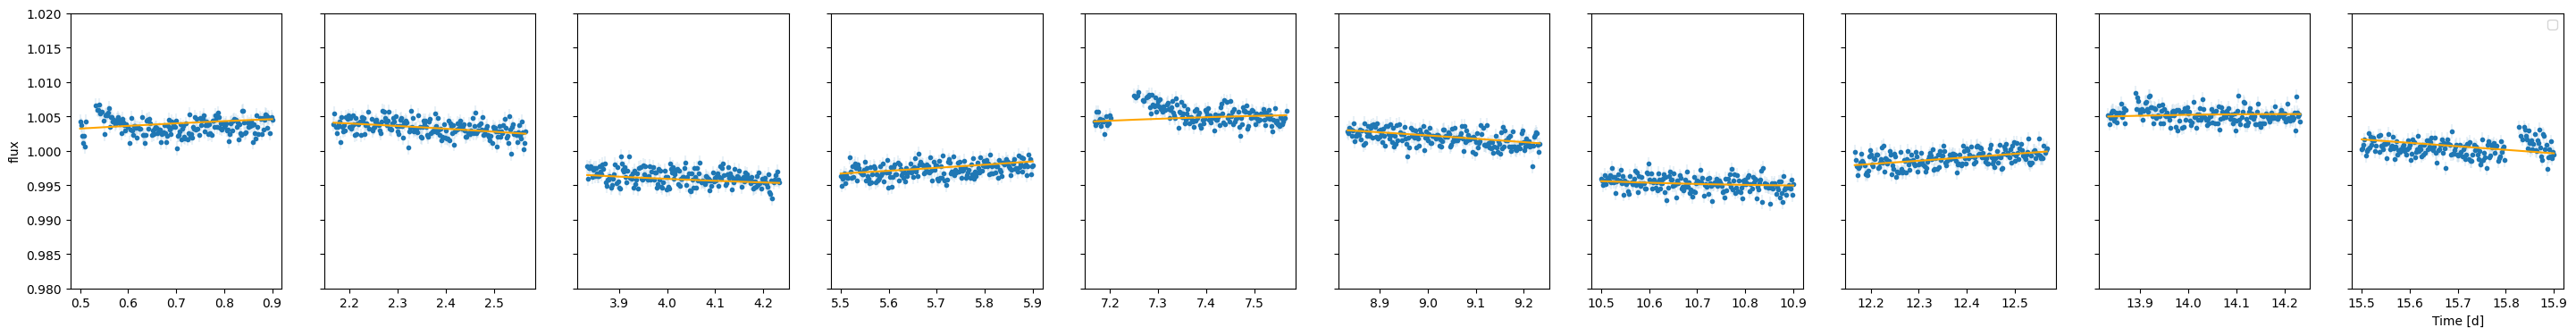

In [10]:
detrended_targ = clip_lc.lombscargle_detrend(plot=True, ls_binning=30*u.minute,
                                  minimum_frequency=1/(30*u.d),
                                  maximum_frequency=1/(0.5*u.d),
                                  samples_per_peak=10,
                                  npeaks=1,
                                  nsigma=3)

In [11]:
flare_lc_detrended = flare_lc._create_copy()
flare_lc_detrended.timelike['flux'] = flare_lc_detrended.timelike['flux']/detrended_targ.timelike['ls_model']

/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



            There are 4 flare candidates with >5.0 min over 3$\sigma$
            


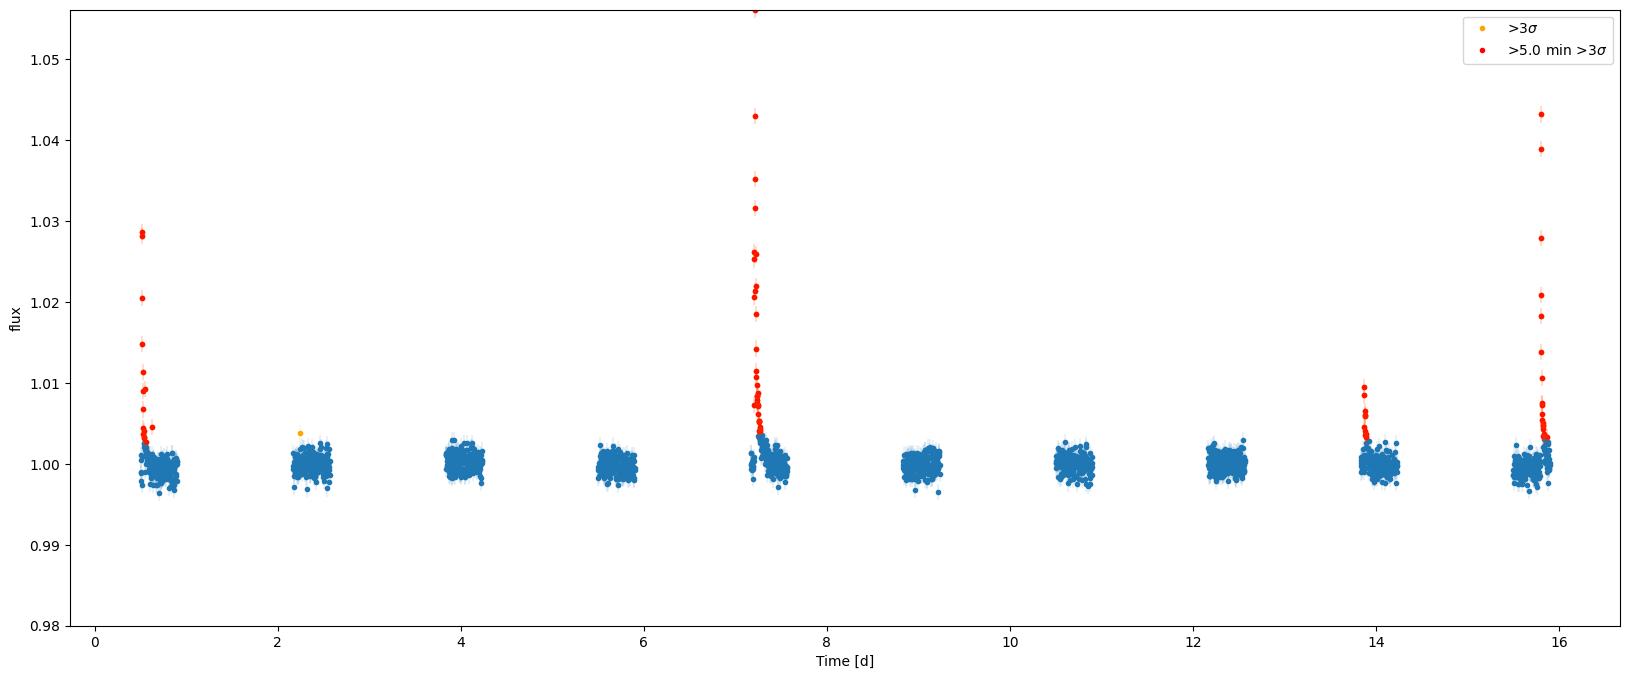

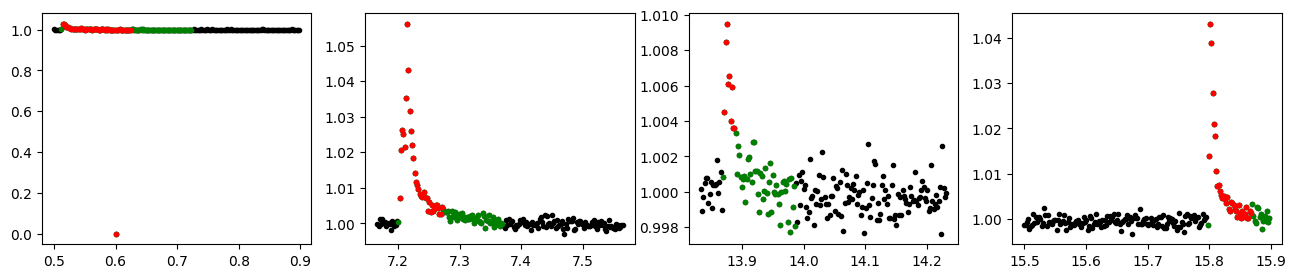

In [36]:
flares_masked = detect_flares_sclip(flare_lc_detrended, plot=True, 
                                                       min_flare_separation=60*u.minute,
                                                       tbuffer_after=0.1*u.d)
                                                      # nbuffer_ after=20)

In [34]:
flares_masked.metadata

{'name': 'test_injectedflares_sigmaclipped_flaresremoved',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [0.514964420692815,
    15.802008261979937,
    13.874845494044044,
    7.207320422217878,
    7.214765217131041],
   'fwhm': [0.0058212179384868525,
    0.006796428235003637,
    0.010804419444843597,
    0.011839557098117346,
    0.006137632550858874],
   'amp': [0.035636103611340085,
    0.04667856624837055,
    0.009535485424857593,
    0.028856248992313236,
    0.04204272219851864]}},
 'flares_detected': {'nflares': 4,
  'thresholds': {'duration': <Quantity 5. min>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[7, 63], [818, 853], [1619, 1628], [1949, 1984]],
  'flare_frequency': <Quantity 1.11111111 1 / d>,
  'global_sc_kw': {'nsigma_upper': 5, 'nsigma_lower': 5},
  'local_sc_kw': {'nsigma_upper': 3,
   'nsigma_lower': inf,
   'running_mean

In [37]:
flares_masked.metadata['flares_detected']

{'nflares': 4,
 'thresholds': {'duration': <Quantity 5. min>,
  'sigma': 3,
  'separation': <Quantity 60. min>},
 'flare_regions': [[6, 112], [817, 902], [1618, 1677], [1948, 1999]],
 'flare_frequency': <Quantity 1.11111111 1 / d>,
 'global_sc_kw': {'nsigma_upper': 5, 'nsigma_lower': 5},
 'local_sc_kw': {'nsigma_upper': 3,
  'nsigma_lower': inf,
  'running_mean_boxsize': 0.4}}

In [35]:
def detect_flares_sclip(self, min_flare_duration=5 * u.minute, min_flare_separation=10*u.minute,
                        n_consecutive_points=3,
                        n_points=3,
                        global_sc_kw={'nsigma_upper': 5, 'nsigma_lower': 5},
                        local_sc_kw={'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_mean_boxsize': 0.4},
                        tbuffer_before = 5*u.minute,
                        tbuffer_after = 15*u.minute,
                        plot=False):
    clip_lc = self._create_copy()
    clip_lc = clip_lc.global_and_local_sigma_clip(global_sc_kw=global_sc_kw, local_sc_kw=local_sc_kw)

    # isolate every sigma-clipped point
    outliers = np.where(np.isnan(clip_lc.flux))[0]
    regions = []

    if len(outliers) == 0:
        print("No flares found.")

    else:
        current_region = [outliers[0]]

        # loop over every detected outlier region
        for o in outliers[1:]:
            # check if the outlier regions are separated by more than the user-defined minimum flare separation
            if (clip_lc.time[o] - clip_lc.time[current_region[-1]]) > min_flare_separation:
                diffs = np.array([(b - a) for a, b in zip(current_region[:-1], current_region[1:])])
                if (len(current_region) > n_points) & (np.count_nonzero(diffs == 1) > n_consecutive_points):
                    t = clip_lc.time[current_region]
                    dur = np.max(t) - np.min(t)
                    if (dur > min_flare_duration) and (dur < self.split_by):
                        regions.append(current_region)
                current_region = [o]
            else:
                current_region.append(o)

        if len(regions) > 0:
            diffs = np.array([(b - a) for a, b in zip(current_region[:-1], current_region[1:])])
            if (len(current_region) > n_points) and (current_region[-1] != regions[-1][-1]) and\
                    (np.count_nonzero(diffs == 1) > n_consecutive_points):
                t = clip_lc.time[current_region]
                dur = np.max(t) - np.min(t)
                if (dur > min_flare_duration) and (dur < self.split_by):
                    regions.append(current_region)

            print(f"""
            There are {len(regions)} flare candidates with >{min_flare_duration} over {local_sc_kw['nsigma_upper']}$\sigma$
            """)

            flare_regions = [[r[0], r[-1]] for r in regions]

            if plot:
                ax = clip_lc.plot_all(figsize=(20, 8))
                self.extract(outliers).plot_all(ax=ax, color='orange', label=f">{local_sc_kw['nsigma_upper']}$\sigma$")
                for i, r in enumerate(regions):
                    if i == 0:
                        self.extract(r).plot_all(ax=ax, color='red',
                                                 label=f">{min_flare_duration} >{local_sc_kw['nsigma_upper']}$\sigma$")
                    else:
                        self.extract(r).plot_all(ax=ax, color='red')

                plt.ylim(0.98, np.nanmax(self.flux))

                # flares = targ_flares_removed.metadata['flares_detected']
                nfl = len(flare_regions)
                fig, ax = plt.subplots(ncols=nfl, figsize=(nfl * 4, 3))

                buffered_flare_regions = []
                for i, f in enumerate(flare_regions):
                    if nfl>1:
                        plt.sca(ax[i])
                    else:
                        plt.sca(ax)

                    # Add user-defined buffer before and after flare
                    t_before_flare = self.time[f[0]] - tbuffer_before
                    t_after_flare = self.time[f[1]] + tbuffer_after
                    start_t = np.where(self.time>t_before_flare)[0][0]
                    end_t = np.where(self.time<t_after_flare)[0][-1]

                    buffered_flare_regions.append([start_t, end_t])

                    i_start = find_nearest(self.time.value, self.time.value[start_t] - 0.35)
                    i_end = find_nearest(self.time.value, self.time.value[end_t] + 0.35)
                    plt.plot(self.time.value[i_start:i_end], self.flux[i_start:i_end], 'k.')
                    plt.plot(self.time.value[start_t:end_t], self.flux[start_t:end_t], 'g.')
                    plt.plot(self.time.value[f[0]:f[1]], self.flux[f[0]:f[1]], 'r.')

            clip_lc.metadata['flares_detected'] = {'nflares': len(buffered_flare_regions),
                                                   'thresholds': {'duration': min_flare_duration,
                                                                 'sigma': local_sc_kw['nsigma_upper'],
                                                                 'separation': min_flare_separation},
                                                   'flare_regions': buffered_flare_regions,
                                                   'flare_frequency': len(buffered_flare_regions)/self.total_time_observed,
                                                   'global_sc_kw':global_sc_kw,
                                                   'local_sc_kw':local_sc_kw
                                          }
            clip_lc.timelike['flux'] = self.flux.copy()
            for r in buffered_flare_regions:
                clip_lc.timelike['flux'][r[0]:r[1]] = np.nan
            clip_lc._set_name(clip_lc.name + "_flaresremoved")
        else:
            print("No flares found.")
    return clip_lc

In [16]:
flare_lc.dt.to('minute')

<Quantity 2.89447236 min>

In [27]:
f = [20, 40]
tbuffer_before = 30*u.minute
tbuffer_after = 30*u.minute
self = flare_lc

t_after_flare = self.time[f[1]] + tbuffer_after
np.where(self.time<t_after_flare)[0][-1]

50

In [13]:
flares_masked.metadata

{'name': 'test_injectedflares_sigmaclipped_flaresremoved',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'flares_injected': {'nflares_injected': 5,
  'flare_params': {'t0': [2.3042434693463827,
    4.2201762489847425,
    2.3868697717293985,
    4.117954037300278,
    12.471274471947552],
   'fwhm': [0.006200729046395185,
    0.011910660762356064,
    0.008102636896233332,
    0.005073992921184112,
    0.005418412844867657],
   'amp': [0.017751792373929043,
    0.032672067306446,
    0.029109164155121575,
    0.03772330635158062,
    0.012752798571977766]}},
 'flares_detected': {'nflares': 5,
  'thresholds': {'duration': <Quantity 5. min>,
   'sigma': 3,
   'separation': <Quantity 60. min>},
  'flare_regions': [[268, 281],
   [308, 327],
   [541, 559],
   [590, 599],
   [1551, 1557]],
  'flare_frequency': <Quantity 1.38888889 1 / d>,
  'global_sc_kw': {'nsigma_upper': 5, 'nsigma_lower': 5},
  'local_sc_kw': {'nsigma_upper': 3,
   'nsigma_lower

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

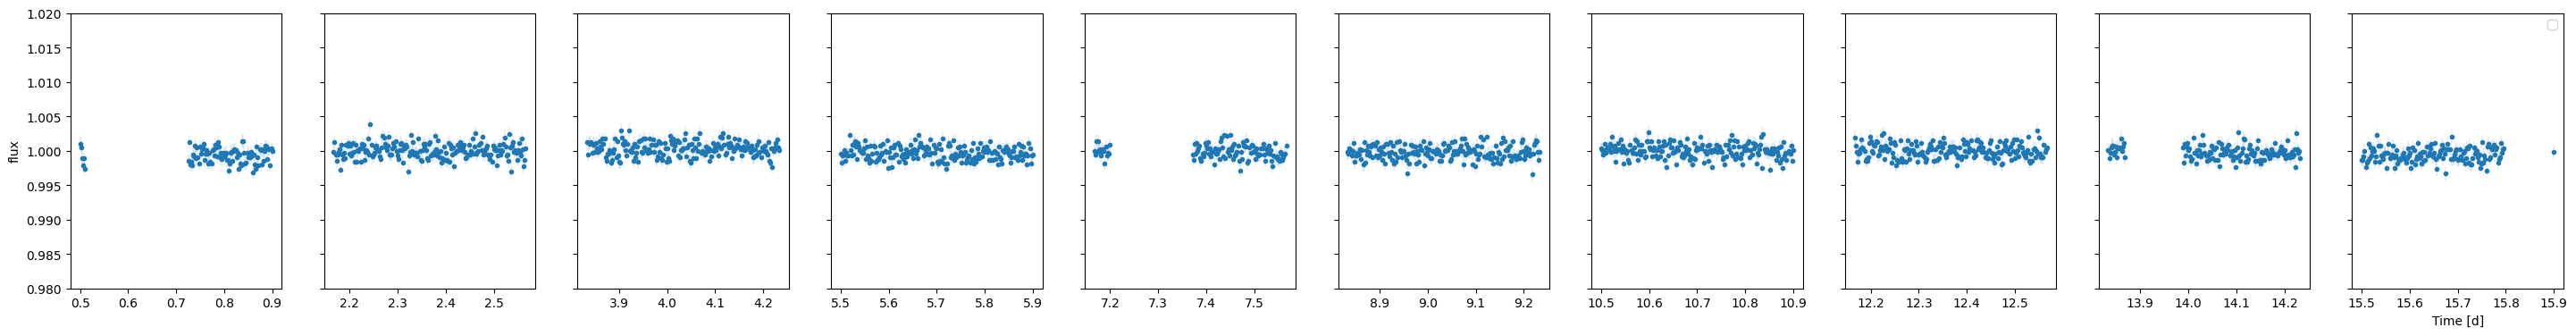

In [38]:
flares_masked.plot()